# AILS модель

В этом ноутбуке я построю матрицу взаимодействия и протестирую AILS модель.

## Импорт библиоткек

In [2]:
!pip install implicit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 2.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for implicit: filename=implicit-0.7.2-cp312-cp312-linux_x86_64.whl size=933263 sha256=ff4b2728b0c4c0479861c5b9ad73888f28b56f22701312564ecdd26fb8601d67
  Stored in directory: /root/.cache/pip/wheels/b2/00/4f/9ff8af07a0a53ac6007ea5d739da19cfe147a2df542b6899f8
Successfully built implicit


In [15]:
import pandas as pd
import numpy as np
import implicit
from scipy import sparse
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Загрузка данных

In [16]:
users_clean = pd.read_csv('users_clean_final.csv')
items_clean = pd.read_csv('items_clean_final.csv')
user_items = pd.read_csv('user_items_final.csv')

## Построение матрицы __User-Item__

Формула для Confidence (weight)

__Weight = 1 + log(N)__, где N - количество посещений

Такая формула была выбрана, потому что она:
1)  Учитывает размерность самых частых услуг (log сгладит услуги с крупными посещениями).
2) Учитывает частоту посещений и поощеряет услугу, если клиент часто на неё ходит.

Тогда матрица будет в формате:

`id_user` | `id_item` | `Weight`

#### Считаем Weight

In [7]:
# 1. Считаем посещения с весами
user_item_matrix = user_items.groupby(['user_id', 'item_id']).size().reset_index(name='N_visits')

# 2. Weight = 1 + log(N)
user_item_matrix['confidence'] = 1 + np.log(user_item_matrix['N_visits'])

#### CSR матрица

In [8]:
rows = user_item_matrix['user_id'].values
cols = user_item_matrix['item_id'].values
data = user_item_matrix['confidence'].values

In [9]:
user_item_sparse = sparse.csr_matrix((data, (rows, cols)),
                                   shape=(users_clean['id_user'].max()+1,
                                          items_clean['id_item'].max()+1))

In [12]:
print(f"Размер матрицы: {user_item_sparse.shape}")
print(f"Веса: {data.min():.2f} → {data.max():.2f}")
print(f"Средний вес: {data.mean():.2f}")

Размер матрицы: (2893, 258)
Веса: 1.00 → 2.39
Средний вес: 1.07


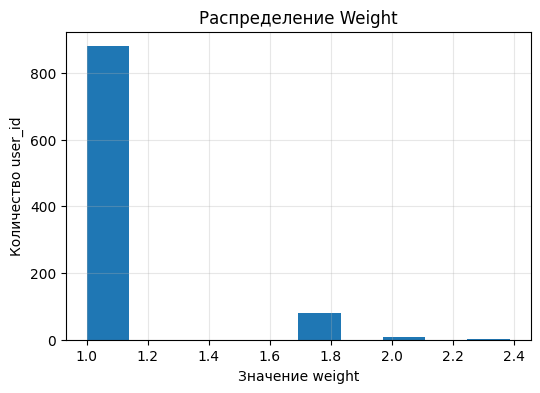

In [21]:
plt.figure(figsize=(6,4))

plt.title('Распределение Weight')
plt.xlabel('Значение weight')
plt.ylabel('Количество user_id')

plt.hist(data)
plt.grid(True, alpha=0.3)
plt.show()